# Librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Problema 1

In [3]:
def activar_canales(imagen, color):
    # Crear una imagen completamente negra
    resultado = np.zeros_like(imagen)

    # Azul
    if color == 1:
        resultado[:, :, 0] = imagen[:, :, 0]

    # Verde
    elif color == 2:
        resultado[:, :, 1] = imagen[:, :, 1]

    # Rojo
    elif color == 3:
        resultado[:, :, 2] = imagen[:, :, 2]

    # Rojo y verde
    elif color == 10:
        resultado[:, :, 1] = imagen[:, :, 1]
        resultado[:, :, 2] = imagen[:, :, 2]

    # Verde y azul
    elif color == 20:
        resultado[:, :, 0] = imagen[:, :, 0]
        resultado[:, :, 1] = imagen[:, :, 1]

    # Azul y rojo
    elif color == 30:
        resultado[:, :, 0] = imagen[:, :, 0]
        resultado[:, :, 2] = imagen[:, :, 2]

    else:
        raise ValueError(
            "El parámetro color debe ser 1, 2, 3, 10, 20 o 30."
        )

    return resultado

## Probar la función

In [5]:
imagen = cv2.imread("perro_salida_gray_azul.jpg")

if imagen is None:
    raise FileNotFoundError("No se pudo encontrar la imagen.")

In [6]:
solo_azul = activar_canales(imagen, 1)
solo_verde = activar_canales(imagen, 2)
solo_rojo = activar_canales(imagen, 3)

rojo_verde = activar_canales(imagen, 10)
verde_azul = activar_canales(imagen, 20)
azul_rojo = activar_canales(imagen, 30)

## Mostrar resultados

In [7]:
def mostrar_imagen(imagen, titulo):
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    plt.imshow(imagen_rgb)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

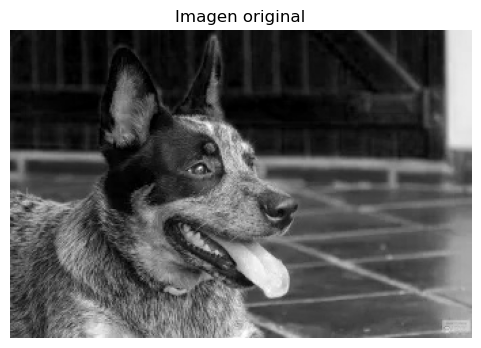

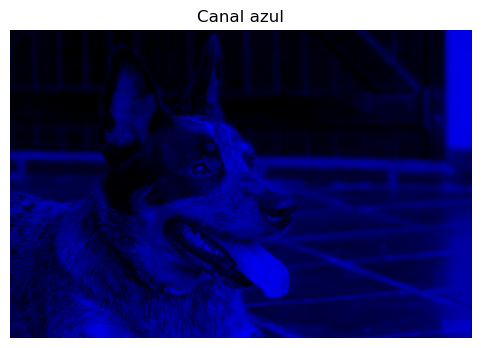

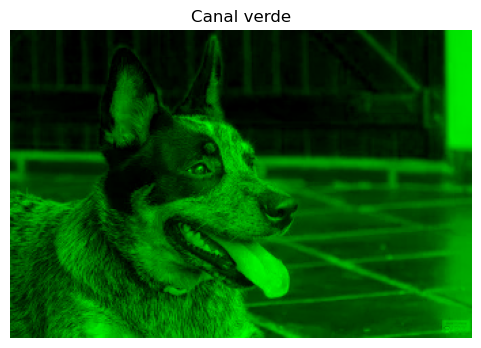

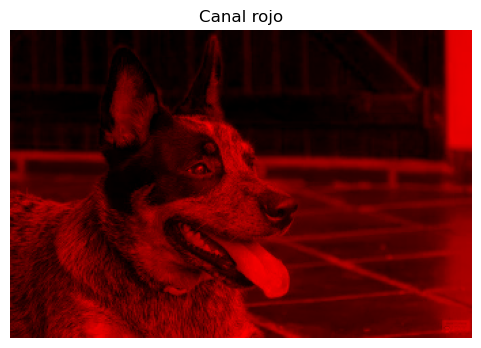

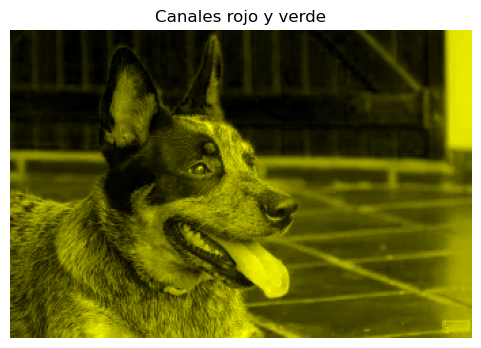

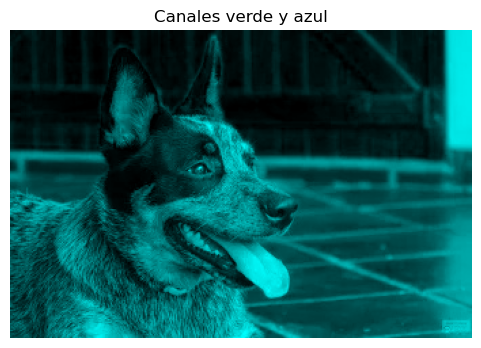

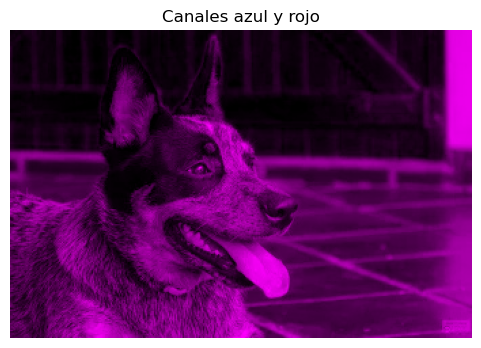

In [8]:
mostrar_imagen(imagen, "Imagen original")
mostrar_imagen(solo_azul, "Canal azul")
mostrar_imagen(solo_verde, "Canal verde")
mostrar_imagen(solo_rojo, "Canal rojo")
mostrar_imagen(rojo_verde, "Canales rojo y verde")
mostrar_imagen(verde_azul, "Canales verde y azul")
mostrar_imagen(azul_rojo, "Canales azul y rojo")

# Problema 2

In [9]:
def reconstruir_color(azul, verde, rojo):

    # Leer imágenes en escala de grises
    canal_azul = cv2.imread(azul, cv2.IMREAD_GRAYSCALE)
    canal_verde = cv2.imread(verde, cv2.IMREAD_GRAYSCALE)
    canal_rojo = cv2.imread(rojo, cv2.IMREAD_GRAYSCALE)

    # Verificar que existan
    if canal_azul is None or canal_verde is None or canal_rojo is None:
        raise FileNotFoundError("No se pudo leer una o más imágenes.")

    # Combinar canales
    imagen_color = cv2.merge((canal_azul, canal_verde, canal_rojo))

    return imagen_color

In [10]:
perro = reconstruir_color(
    "perro_salida_gray_azul.jpg",
    "perro_salida_gray_verde.jpg",
    "perro_salida_gray_rojo.jpg"
)

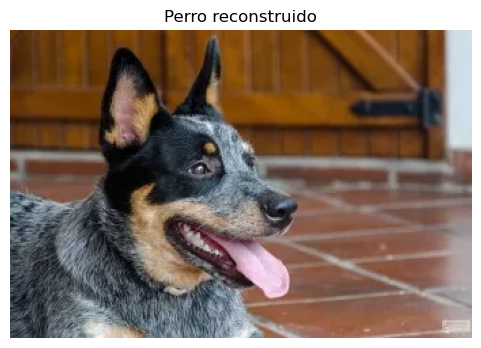

In [11]:
mostrar_imagen(perro, "Perro reconstruido")

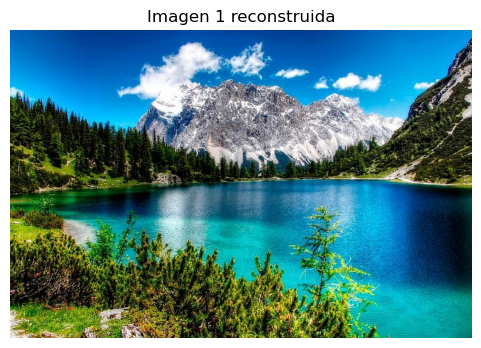

In [12]:
imagen1 = reconstruir_color(
    "imagen1_salida_gray_azul.jpg",
    "imagen1_salida_gray_verde.jpg",
    "imagen1_salida_gray_rojo.jpg"
)

mostrar_imagen(imagen1, "Imagen 1 reconstruida")

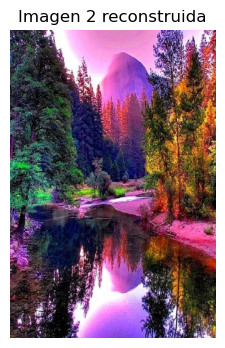

In [13]:
imagen2 = reconstruir_color(
    "imagen2_salida_gray_azul.jpg",
    "imagen2_salida_gray_verde.jpg",
    "imagen2_salida_gray_rojo.jpg"
)

mostrar_imagen(imagen2, "Imagen 2 reconstruida")

# Problema 3

In [21]:
def crear_grises_3d(imagen):

    azul = imagen[:, :, 0]
    verde = imagen[:, :, 1]
    rojo = imagen[:, :, 2]

    return azul, verde, rojo

In [25]:
imagen = cv2.imread("imagen3.jpeg")

In [27]:
azul, verde, rojo = crear_grises_3d(imagen)

In [28]:
print(azul.shape)
print(verde.shape)
print(rojo.shape)

(529, 378)
(529, 378)
(529, 378)


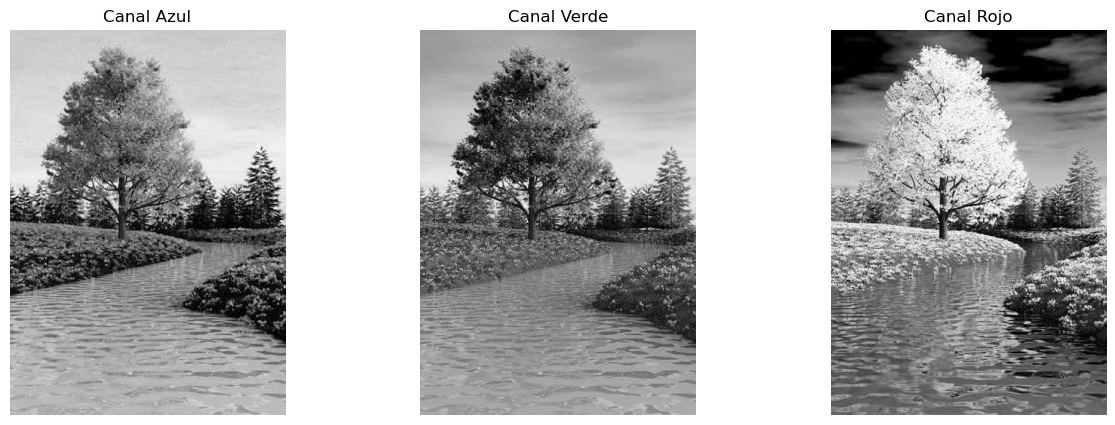

In [29]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(azul, cmap="gray")
plt.title("Canal Azul")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(verde, cmap="gray")
plt.title("Canal Verde")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rojo, cmap="gray")
plt.title("Canal Rojo")
plt.axis("off")

plt.show()

# Problema 4

In [30]:
gris = ((imagen[:, :, 0].astype(np.float32) +
         imagen[:, :, 1].astype(np.float32) +
         imagen[:, :, 2].astype(np.float32)) / 3).astype(np.uint8)

In [31]:
def mostrar_histograma(canal, titulo, color):

    plt.figure(figsize=(6,4))

    plt.hist(canal.ravel(),
             bins=256,
             range=[0,256],
             color=color)

    media = np.mean(canal)

    plt.axvline(media,
                color="black",
                linestyle="--",
                linewidth=2,
                label=f"Media = {media:.2f}")

    plt.title(titulo)
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.legend()

    plt.show()

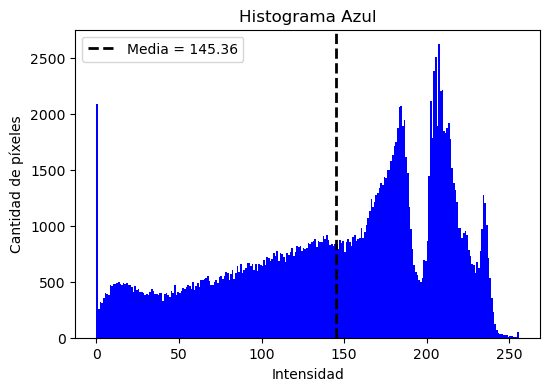

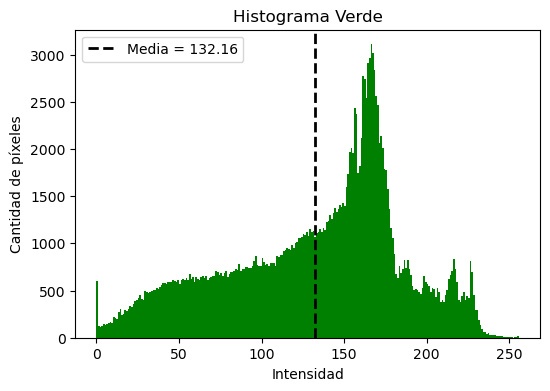

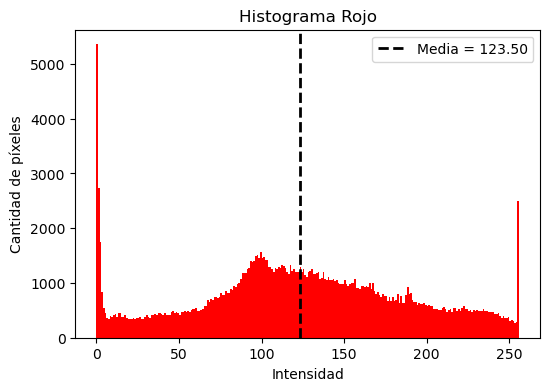

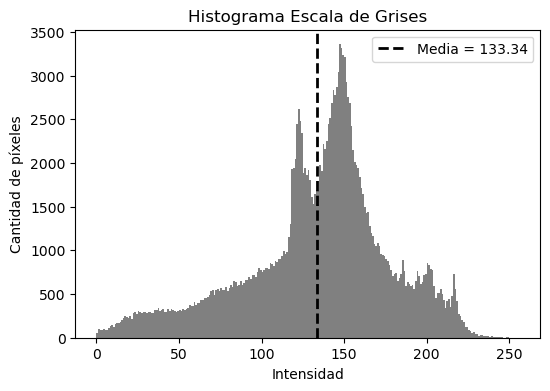

In [32]:
mostrar_histograma(imagen[:, :, 0], "Histograma Azul", "blue")

mostrar_histograma(imagen[:, :, 1], "Histograma Verde", "green")

mostrar_histograma(imagen[:, :, 2], "Histograma Rojo", "red")

mostrar_histograma(gris, "Histograma Escala de Grises", "gray")

# Problema 5

In [33]:
def escala_grises_ponderada(imagen):

    azul = imagen[:, :, 0].astype(np.float32)
    verde = imagen[:, :, 1].astype(np.float32)
    rojo = imagen[:, :, 2].astype(np.float32)

    gris = (
        0.114 * azul +
        0.587 * verde +
        0.299 * rojo
    )

    return gris.astype(np.uint8)

In [34]:
gris_ponderado = escala_grises_ponderada(imagen)

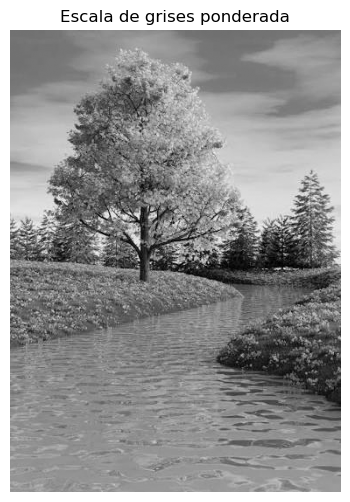

In [35]:
plt.figure(figsize=(6,6))

plt.imshow(gris_ponderado, cmap="gray")

plt.title("Escala de grises ponderada")

plt.axis("off")

plt.show()

## Escala de grises ponderada

La escala de grises ponderada asigna diferente importancia a cada canal de color, ya que el ojo humano percibe con mayor intensidad el color verde, seguido del rojo y finalmente el azul. Para este laboratorio se utilizó la fórmula:

Gray = 0.299R + 0.587G + 0.114B

Este método produce imágenes en escala de grises más similares a la percepción humana que un promedio aritmético simple.

# Problema 6 - Espacio de color HSV

El espacio de color HSV representa los colores utilizando tres componentes:

- **H (Hue o Matiz):** Representa el tipo de color. Se mide en grados alrededor de una rueda de colores. Por ejemplo:
  - 0°: Rojo
  - 60°: Amarillo
  - 120°: Verde
  - 180°: Cian
  - 240°: Azul
  - 300°: Magenta

- **S (Saturation o Saturación):** Indica la intensidad o pureza del color.
  - Saturación baja: colores cercanos al gris.
  - Saturación alta: colores vivos e intensos.

- **V (Value o Brillo):** Representa la luminosidad del color.
  - Valor bajo: colores oscuros.
  - Valor alto: colores brillantes.

Una ventaja del espacio HSV es que separa el color de la iluminación, lo que facilita tareas de segmentación, detección de objetos y procesamiento de imágenes en comparación con el espacio RGB.